# XGBoost Classification – NB2: Imputation + Outlier Clipping

## Goal
Test whether better **stress-data preparation** improves the stress-test accuracy of the XGBoost classifier.

## Starting point (NB1)

| max_depth | Acc Test | Gap (train − test) | Acc Stress (native NaN) |
|---|---|---|---|
| 3 | **67.1%** | **24.1** | 22.0% |
| 5 | 66.7% | 33.2 | 22.0% |
| 7 | 65.4% | 34.6 | 22.0% |

**max_depth=3** is the new baseline.

## What this notebook does
The model is trained **once**, exactly as in NB1. Only the preparation of the stress data changes:

- **Step A – Outlier clipping:** limit stress values to the training range
- **Step B – 4 leakage-free imputation methods**, each with and without clipping = 8 runs
- **Step C – Leakage demonstration:** the "median per meat_type" fill used in the RF classification, marked as invalid
- **Step D – Comparison of all results**

## Expectation
NB1 showed the stress test fails because of a **price shift** (+6 to +10 € per meat type), not because of missing values. This notebook checks that systematically.

## Step 1 – Imports

New compared to NB1:
- `KNNImputer` – fills NaN from the 5 most similar rows
- `IterativeImputer` – predicts each missing feature from the other features. It is still marked *experimental* in sklearn, so it needs an extra enable-import.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (required to unlock IterativeImputer)
from sklearn.impute import IterativeImputer

RANDOM_STATE = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

## Step 2 – Load data, label shift, split

Identical to NB1: same `random_state=42` and stratified 80/20 split, so the test set is exactly the same and results stay comparable.

Labels are shifted from 1–5 to 0–4 (XGBoost requirement).

In [2]:
df = pd.read_csv("meat_price_dataset.csv")
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

TARGET = "meat_type"
FEATURES = [c for c in df.columns if c != TARGET]
CLASS_NAMES = ["1", "2", "3", "4", "5"]

X = df[FEATURES]
y = df[TARGET].astype(int) - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Stress data: rows without a true label cannot be evaluated
stress = df_stress.dropna(subset=[TARGET]).copy()
X_stress = stress[FEATURES]
y_stress = stress[TARGET].astype(int) - 1

print("Train:", X_train.shape, " Test:", X_test.shape, " Stress:", X_stress.shape)

Train: (960, 8)  Test: (240, 8)  Stress: (91, 8)


## Step 3 – Train the baseline model (max_depth=3)

Same parameters as NB1, except `max_depth=3`, the best setting from the depth check.

In [3]:
model = XGBClassifier(
    objective="multi:softprob",
    n_estimators=150,
    learning_rate=0.08,
    max_depth=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))
print(f"Train accuracy: {acc_train:.2%}")
print(f"Test accuracy:  {acc_test:.2%}")
print(f"Gap:            {acc_train - acc_test:.2%}")

Train accuracy: 91.15%
Test accuracy:  67.08%
Gap:            24.06%


## Step A – Outlier clipping

### What is clipping?
Every stress value outside the training range gets set to the nearest training boundary:

```
animal_age_months = 189  ->  clipped to training max 71
marbling_score    = 0    ->  clipped to training min 1
```

### Why can it help?
A tree model cannot extrapolate. A value of 189 months already lands in the same leaf as 71 months, so for **pure tree splits** clipping changes almost nothing. It matters more for the **imputers in Step B**: KNN uses distances, and one extreme value like 189 distorts which rows count as "similar".

### Order of operations
**Clip first, then impute.** The imputers then work with values in a realistic range. NaN values are not touched by clipping.

In [4]:
train_min = X_train.min()
train_max = X_train.max()

def clip_to_train(X_in):
    """Clip each feature to the training min/max. NaN stays NaN."""
    return X_in.clip(lower=train_min, upper=train_max, axis=1)

X_stress_clipped = clip_to_train(X_stress)

changed = (X_stress.fillna(-999) != X_stress_clipped.fillna(-999)).sum()
print("Values changed by clipping, per feature:")
print(changed[changed > 0])
print(f"\nTotal values clipped: {changed.sum()}")

Values changed by clipping, per feature:
fat_content_pct      3
marbling_score       2
animal_age_months    2
storage_days         2
price_eur_per_kg     4
dtype: int64

Total values clipped: 13


## Step B – Leakage-free imputation

### The 4 methods

| # | Method | How it fills a NaN |
|---|---|---|
| 1 | **Native NaN** | No filling. XGBoost sends the NaN down a default branch at every split. |
| 2 | **Global median** | Median of that feature in the training data |
| 3 | **KNN (k=5)** | Average of that feature in the 5 most similar training rows |
| 4 | **Iterative** | A small regression model predicts the missing feature from all other features, repeated in rounds until the fills stabilise |

### The leakage rule
Every imputer is **fitted on `X_train` only**, and the target `meat_type` is **never** used. The imputer learns *how features relate to each other* from training data, then applies that to the stress data.

### Rounding
KNN and Iterative produce decimals (e.g. `organic = 0.4`, `cut_quality = 2.7`). These features are integers in reality, so we round them after imputation to keep the values realistic.

### Scaling note
KNN measures distances. Without scaling, `animal_age_months` (range 2–71) would dominate `organic` (0–1). We therefore scale before KNN and scale back afterwards.

In [5]:
from sklearn.preprocessing import StandardScaler

INT_FEATURES = ["marbling_score", "animal_age_months", "storage_days", "organic", "cut_quality"]

def round_int_features(X_in):
    X_out = X_in.copy()
    X_out[INT_FEATURES] = X_out[INT_FEATURES].round()
    return X_out

# --- Fit all imputers on training data only ---
train_medians = X_train.median()

scaler = StandardScaler().fit(X_train)
knn = KNNImputer(n_neighbors=5).fit(scaler.transform(X_train))

iterative = IterativeImputer(max_iter=10, random_state=RANDOM_STATE).fit(X_train)

def impute(X_in, method):
    """Return a filled copy of X_in using the given method."""
    if method == "Native NaN":
        return X_in.copy()
    if method == "Global median":
        return X_in.fillna(train_medians)
    if method == "KNN":
        filled = scaler.inverse_transform(knn.transform(scaler.transform(X_in)))
        return round_int_features(pd.DataFrame(filled, columns=FEATURES, index=X_in.index))
    if method == "Iterative":
        filled = iterative.transform(X_in)
        return round_int_features(pd.DataFrame(filled, columns=FEATURES, index=X_in.index))
    raise ValueError(method)

METHODS = ["Native NaN", "Global median", "KNN", "Iterative"]
print("Imputers fitted on training data.")

Imputers fitted on training data.


### Running all 8 combinations

For every combination we record:
- **Accuracy** and the **number of correct predictions out of 91**. With only 91 rows, one sample = 1.1 percentage points, so the raw count keeps the differences in perspective.
- **Macro F1** – the average F1 over all 5 classes, which also punishes a model that ignores a class

In [6]:
rows = []
predictions = {}

for clip in [False, True]:
    X_base = X_stress_clipped if clip else X_stress
    for method in METHODS:
        X_ready = impute(X_base, method)
        y_pred = model.predict(X_ready)
        name = f"{method}{' + clip' if clip else ''}"
        predictions[name] = y_pred
        rows.append({
            "Variant": name,
            "Clipping": "yes" if clip else "no",
            "Correct / 91": int((y_pred == y_stress.values).sum()),
            "Accuracy": accuracy_score(y_stress, y_pred),
            "Macro F1": f1_score(y_stress, y_pred, average="macro"),
        })

results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display_results = results.copy()
display_results["Accuracy"] = (display_results["Accuracy"] * 100).round(2).astype(str) + " %"
display_results["Macro F1"] = display_results["Macro F1"].round(3)
print(display_results.to_string(index=False))

             Variant Clipping  Correct / 91 Accuracy  Macro F1
           Iterative       no            21  23.08 %     0.198
          Native NaN       no            20  21.98 %     0.169
                 KNN       no            20  21.98 %     0.184
   Native NaN + clip      yes            20  21.98 %     0.169
    Iterative + clip      yes            20  21.98 %     0.180
          KNN + clip      yes            20  21.98 %     0.184
       Global median       no            19  20.88 %     0.159
Global median + clip      yes            19  20.88 %     0.159


## Step C – Leakage demonstration (INVALID – reference only)

In the Random Forest classification, "domain-based imputation" filled each NaN with the median of its **own `meat_type` group**:

```
fat_content NaN, meat_type = 1  ->  median fat of meat_type 1
```

For **regression** (target = price) this is fine, because `meat_type` is a feature there.
For **classification** (target = `meat_type`) it is **data leakage**: to fill the input, we look at the answer. In a real application the meat type would be unknown, since predicting it is the whole point.

Here we reproduce that method to measure **how much leakage inflates the score**. This result is **not** a valid model result.

In [7]:
# Median of each feature per meat_type, from training data (labels shifted back to 1-5)
group_medians = X_train.assign(meat_type=y_train + 1).groupby("meat_type").median()

def leaky_fill(X_in, true_labels):
    """Fill NaN with the training median of the row's TRUE meat_type. Uses the target -> leakage!"""
    X_out = X_in.copy()
    for mt in group_medians.index:
        mask = (true_labels + 1) == mt
        X_out.loc[mask] = X_out.loc[mask].fillna(group_medians.loc[mt])
    return X_out

y_pred_leaky = model.predict(leaky_fill(X_stress, y_stress))
acc_leaky = accuracy_score(y_stress, y_pred_leaky)

best_valid = results.iloc[0]
print(f"Best valid variant:  {best_valid['Variant']:<22} {best_valid['Accuracy']:.2%} "
      f"({best_valid['Correct / 91']}/91)")
print(f"Leaky group median:  {'(INVALID)':<22} {acc_leaky:.2%} "
      f"({int((y_pred_leaky == y_stress.values).sum())}/91)")
print(f"\nInflation from leakage: {(acc_leaky - best_valid['Accuracy']) * 100:+.2f} percentage points")

Best valid variant:  Iterative              23.08% (21/91)
Leaky group median:  (INVALID)              26.37% (24/91)

Inflation from leakage: +3.30 percentage points


### How to read this
- **Leaky score clearly higher:** the model profits from the answer hidden in the filled values. The RF "domain-based" 27.47% was then partly inflated.
- **Leaky score about equal:** with only ~8 NaN per feature, the leakage had little practical effect, and the RF result is roughly fair. The method is still wrong in principle and should not be reused for classification.

## Step D – Best variant in detail

Per-class report and confusion matrix for the best valid variant. The key question: **does the pattern from NB1 change?**
- Class 1 recall ~0.11 (cheap meat not recognised)
- Class 5 recall ~0.79 (everything pushed toward expensive)

If the pattern stays the same, the preparation did not touch the real problem, the price shift.

Best variant: Iterative

              precision    recall  f1-score   support

           1       0.67      0.11      0.19        18
           2       0.40      0.12      0.18        17
           3       0.05      0.08      0.06        12
           4       0.14      0.12      0.13        25
           5       0.31      0.68      0.43        19

    accuracy                           0.23        91
   macro avg       0.31      0.22      0.20        91
weighted avg       0.32      0.23      0.20        91



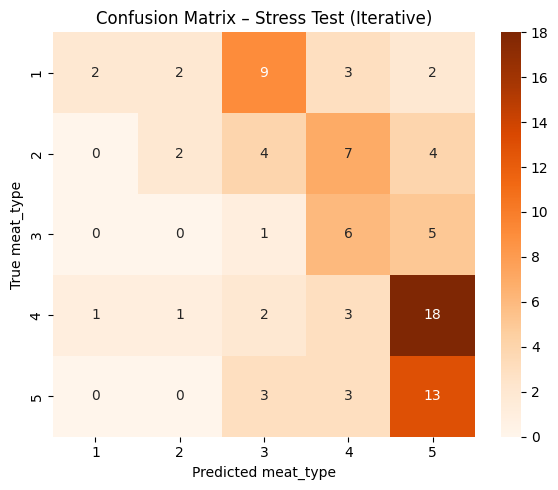

In [8]:
best_name = results.iloc[0]["Variant"]
y_pred_best = predictions[best_name]

print(f"Best variant: {best_name}\n")
print(classification_report(y_stress, y_pred_best, labels=range(5),
                            target_names=CLASS_NAMES, digits=2, zero_division=0))

cm = confusion_matrix(y_stress, y_pred_best, labels=range(5))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted meat_type")
plt.ylabel("True meat_type")
plt.title(f"Confusion Matrix – Stress Test ({best_name})")
plt.tight_layout()
plt.show()

### Recall per class across all variants

If the preparation method really mattered, the recall pattern would change between variants. A stable pattern means the stress failure comes from somewhere else.

In [9]:
recall_table = pd.DataFrame({
    name: pd.Series(
        classification_report(y_stress, pred, labels=range(5), target_names=CLASS_NAMES,
                              output_dict=True, zero_division=0)
    ).loc[CLASS_NAMES].apply(lambda d: d["recall"])
    for name, pred in predictions.items()
}).T.round(2)
recall_table.columns = [f"Recall class {c}" for c in CLASS_NAMES]
print(recall_table.to_string())

                      Recall class 1  Recall class 2  Recall class 3  Recall class 4  Recall class 5
Native NaN                      0.11            0.06            0.08            0.04            0.79
Global median                   0.06            0.06            0.08            0.08            0.74
KNN                             0.11            0.12            0.08            0.04            0.74
Iterative                       0.11            0.12            0.08            0.12            0.68
Native NaN + clip               0.11            0.06            0.08            0.04            0.79
Global median + clip            0.06            0.06            0.08            0.08            0.74
KNN + clip                      0.11            0.12            0.08            0.04            0.74
Iterative + clip                0.06            0.12            0.08            0.12            0.68


## Step E – Comparison with previous models

In [10]:
comparison = pd.DataFrame({
    "Model": [
        "DT baseline",
        "RF baseline (KNN)",
        "RF domain imputation (leaky)",
        "RF + target encoding",
        "XGB NB1 depth 3 – native NaN",
        f"XGB NB2 best – {best_name}",
    ],
    "Acc Test": ["53.0 %", "56.0 %", "56.0 %", "62.5 %",
                 f"{acc_test*100:.1f} %", f"{acc_test*100:.1f} %"],
    "Acc Stress": ["27 %", "24 %", "27.5 %", "25 %", "22.0 %",
                   f"{results.iloc[0]['Accuracy']*100:.1f} %"],
})
print(comparison.to_string(index=False))

                       Model Acc Test Acc Stress
                 DT baseline   53.0 %       27 %
           RF baseline (KNN)   56.0 %       24 %
RF domain imputation (leaky)   56.0 %     27.5 %
        RF + target encoding   62.5 %       25 %
XGB NB1 depth 3 – native NaN   67.1 %     22.0 %
    XGB NB2 best – Iterative   67.1 %     23.1 %


## Summary and next steps

Questions to answer from the results:

1. **Clipping:** Did it change any prediction at all? Which imputers profited from it?
2. **Imputation:** How far apart are the best and worst of the 8 variants, in **samples** out of 91?
3. **Leakage:** How much did the leaky group median inflate the score? Is the RF 27.5% still a fair benchmark?
4. **Recall pattern:** Is class 1 still missed and class 5 still over-predicted in every variant?

If all variants stay within a few samples of each other and the recall pattern stays stable, NB2 **confirms** that stress-data preparation cannot fix a **distribution shift**. The model has to *see* the shifted data during training.

### Next notebook
- **NB3 – Target encoding** or **NB4 – Combined dataset training** (the regression breakthrough: stress R² −0.36 → +0.20)